**Adult Income**


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataPath = 'Data' # path to folder containing the adult Income data
dataFile = os.path.join(dataPath,'adult_sample.csv') # data file to use

In [ ]:
# Load data and labels
df = pd.read_csv(dataFile, header=None, names=['age','workclass','education','education-num','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country','income'])
df.sample(10) # Let's take a random sample from the full data frame

,age,workclass,education,education-num,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
31,30.0,Local-gov,Assoc-voc,11,Protective-serv,Not-in-family,White,Male,0.0,0,40,United-States,<=50K
913,29.0,Private,Assoc-voc,11,Sales,Not-in-family,Black,Male,0.0,0,45,United-States,<=50K
454,32.0,Private,Some-college,10,Adm-clerical,Not-in-family,White,Male,0.0,0,30,United-States,<=50K
1171,28.0,Self-emp-not-inc,Masters,14,Prof-specialty,Own-child,White,Male,0.0,0,40,United-States,<=50K
965,51.0,NaN,HS-grad,9,NaN,Not-in-family,Black,Male,0.0,0,6,United-States,<=50K
1336,28.0,Private,Some-college,10,Machine-op-inspct,Own-child,White,Male,0.0,0,60,United-States,<=50K
1128,37.0,Private,Some-college,10,Machine-op-inspct,Husband,White,Male,0.0,0,70,United-States,<=50K
1953,62.0,Private,Some-college,10,Adm-clerical,Wife,White,Female,0.0,0,38,United-States,>50K
1197,45.0,Local-gov,Bachelors,13,Exec-managerial,Not-in-family,White,Male,0.0,0,40,United-States,<=50K
957,57.0,Private,Masters,14,Exec-managerial,Husband,Black,Male,0.0,1977,40,United-States,>50K


In [ ]:
df.info() # quick information concerning the dataframe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1917 non-null   float64
 1   workclass       1842 non-null   object 
 2   education       1967 non-null   object 
 3   education-num   1967 non-null   int64  
 4   occupation      1842 non-null   object 
 5   relationship    1967 non-null   object 
 6   race            1967 non-null   object 
 7   sex             1967 non-null   object 
 8   capital-gain    1932 non-null   float64
 9   capital-loss    1967 non-null   int64  
 10  hours-per-week  1967 non-null   int64  
 11  native-country  1967 non-null   object 
 12  income          1967 non-null   object 
dtypes: float64(2), int64(3), object(8)
memory usage: 199.9+ KB


In [ ]:
df["income"].value_counts() # distribution concerning the dataframe label

,count
income,
<=50K,1672
>50K,295


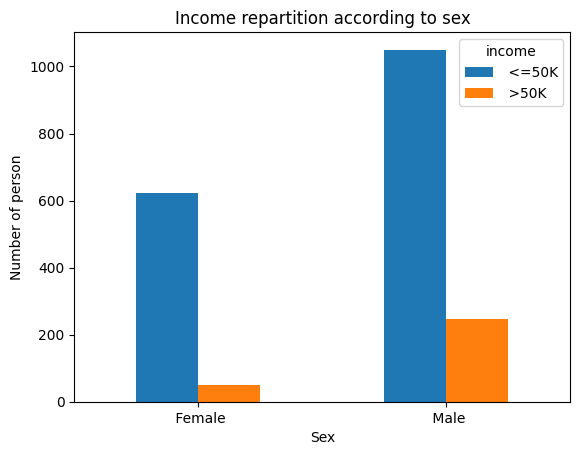

In [ ]:
# Let's analyze one feature (sex) according to the label (income)
counts = df.groupby(["sex", "income"]).size().unstack()

# Let's display the graphic
counts.plot(kind='bar', stacked=False)
plt.title("Income repartition according to sex")
plt.ylabel("Number of person")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import os

# Explicitly set the current working directory to /content/
# This assumes the notebook is located in /content/ and the 'Data' folder is /content/Data.
os.chdir('/content/')

print(f"Changed current directory to: {os.getcwd()}")

Changed current directory to: /content


In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report


# Dictionary to store models and their accuracies
models = {}
accuracies = {}

# 1. Sélectionner toutes les colonnes dont on a besoin
features_list = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'occupation', 'relationship', 'race', 'sex', 'native-country']
all_cols = features_list + categorical_cols + ['income']

# 2. Dropna sur TOUTES les colonnes utilisées et faire une COPIE explicite
df_clean = df[all_cols].dropna().copy()

# Encode target variable
le_income = LabelEncoder()
df_clean['income_encoded'] = le_income.fit_transform(df_clean['income'])

# 3. Encodage (sans risque de SettingWithCopyWarning)
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col])
    le_dict[col] = le

le_income = LabelEncoder()
df_clean['income_encoded'] = le_income.fit_transform(df_clean['income'])

# 4. Définir X et y
# X = df_clean[[col for col in df_clean.columns if '_encoded' in col or col in features_list and col != 'income']]
X = df_clean[['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week'] +
             [col + '_encoded' for col in categorical_cols]]
y = df_clean['income_encoded']

# VÉRIFICATION DE SÉCURITÉ
if X.isnull().values.any():
    print("Attention: Il reste des NaN dans X !")
    X = X.fillna(0) # Solution de secours

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Decision Tree (already trained)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_dt)
models['Decision Tree'] = dt_classifier
accuracies['Decision Tree'] = accuracy

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Linear SVM
svm_linear = LinearSVC(random_state=42, max_iter=2000)
svm_linear.fit(X_train_pca, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_pca)
accuracies['Linear SVM'] = accuracy_score(y_test, y_pred_svm_linear)
models['Linear SVM'] = svm_linear

# Non-linear SVM (RBF)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_pca, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_pca)
accuracies['Non-linear SVM'] = accuracy_score(y_test, y_pred_svm_rbf)
models['Non-linear SVM'] = svm_rbf

# MLP
mlp_classifier = MLPClassifier(random_state=42, max_iter=500)
mlp_classifier.fit(X_train_pca, y_train)
y_pred_mlp = mlp_classifier.predict(X_test_pca)
accuracies['MLP'] = accuracy_score(y_test, y_pred_mlp)
models['MLP'] = mlp_classifier

# 2. Random Forest
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
accuracies['Random Forest'] = accuracy_score(y_test, y_pred_rf)
models['Random Forest'] = rf_classifier

# 3. Gradient Boosting
gb_classifier = GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5)
gb_classifier.fit(X_train, y_train)
y_pred_gb = gb_classifier.predict(X_test)
accuracies['Gradient Boosting'] = accuracy_score(y_test, y_pred_gb)
models['Gradient Boosting'] = gb_classifier

# 4. Logistic Regression
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_train, y_train)
y_pred_lr = lr_classifier.predict(X_test)
accuracies['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
models['Logistic Regression'] = lr_classifier

# 5. K-Nearest Neighbors
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)
accuracies['K-Nearest Neighbors'] = accuracy_score(y_test, y_pred_knn)
models['K-Nearest Neighbors'] = knn_classifier

# 6. Naive Bayes
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred_nb = nb_classifier.predict(X_test)
accuracies['Naive Bayes'] = accuracy_score(y_test, y_pred_nb)
models['Naive Bayes'] = nb_classifier

# Display results
print("Model Comparison:")
print("-" * 50)
for model_name, acc in sorted(accuracies.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25s}: {acc:.4f}")

# Find the best model
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]
best_accuracy = accuracies[best_model_name]

print("\n" + "=" * 50)
print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")
print("=" * 50)

# Display detailed classification report for the best model
y_pred_best = best_model.predict(X_test)
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le_income.classes_))


confusion_matrix = pd.crosstab(y_test, y_pred_best, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

Model Comparison:
--------------------------------------------------
Random Forest            : 0.8785
Linear SVM               : 0.8588
Non-linear SVM           : 0.8559
Logistic Regression      : 0.8559
Gradient Boosting        : 0.8503
K-Nearest Neighbors      : 0.8446
Decision Tree            : 0.8305
Naive Bayes              : 0.8277
MLP                      : 0.8136

Best Model: Random Forest
Best Accuracy: 0.8785

Classification Report for Random Forest:
              precision    recall  f1-score   support

       <=50K       0.89      0.98      0.93       297
        >50K       0.77      0.35      0.48        57

    accuracy                           0.88       354
   macro avg       0.83      0.67      0.71       354
weighted avg       0.87      0.88      0.86       354

Confusion Matrix:
Predicted    0   1
Actual            
0          291   6
1           37  20


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
confusion_matrix = pd.crosstab(y_test, y_pred_best, rownames=['Actual'], colnames=['Predicted'])
print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
Predicted    0   1
Actual            
0          291   6
1           37  20


/tmp/ipython-input-3451394165.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_values, palette='viridis')


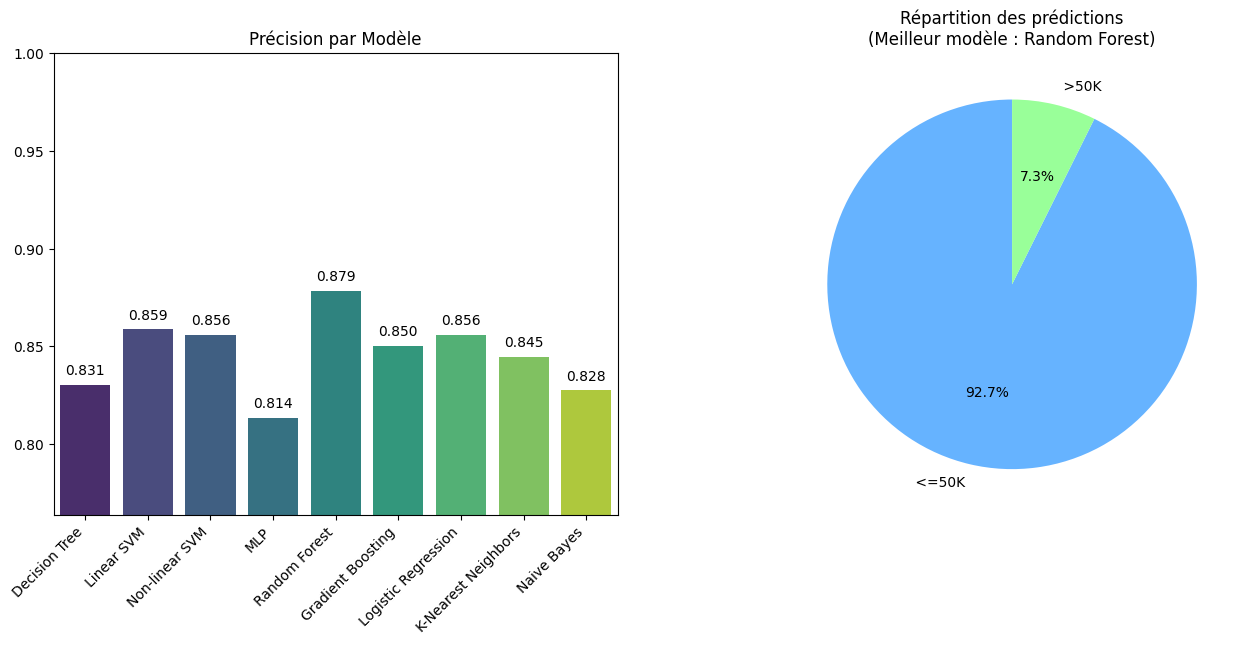

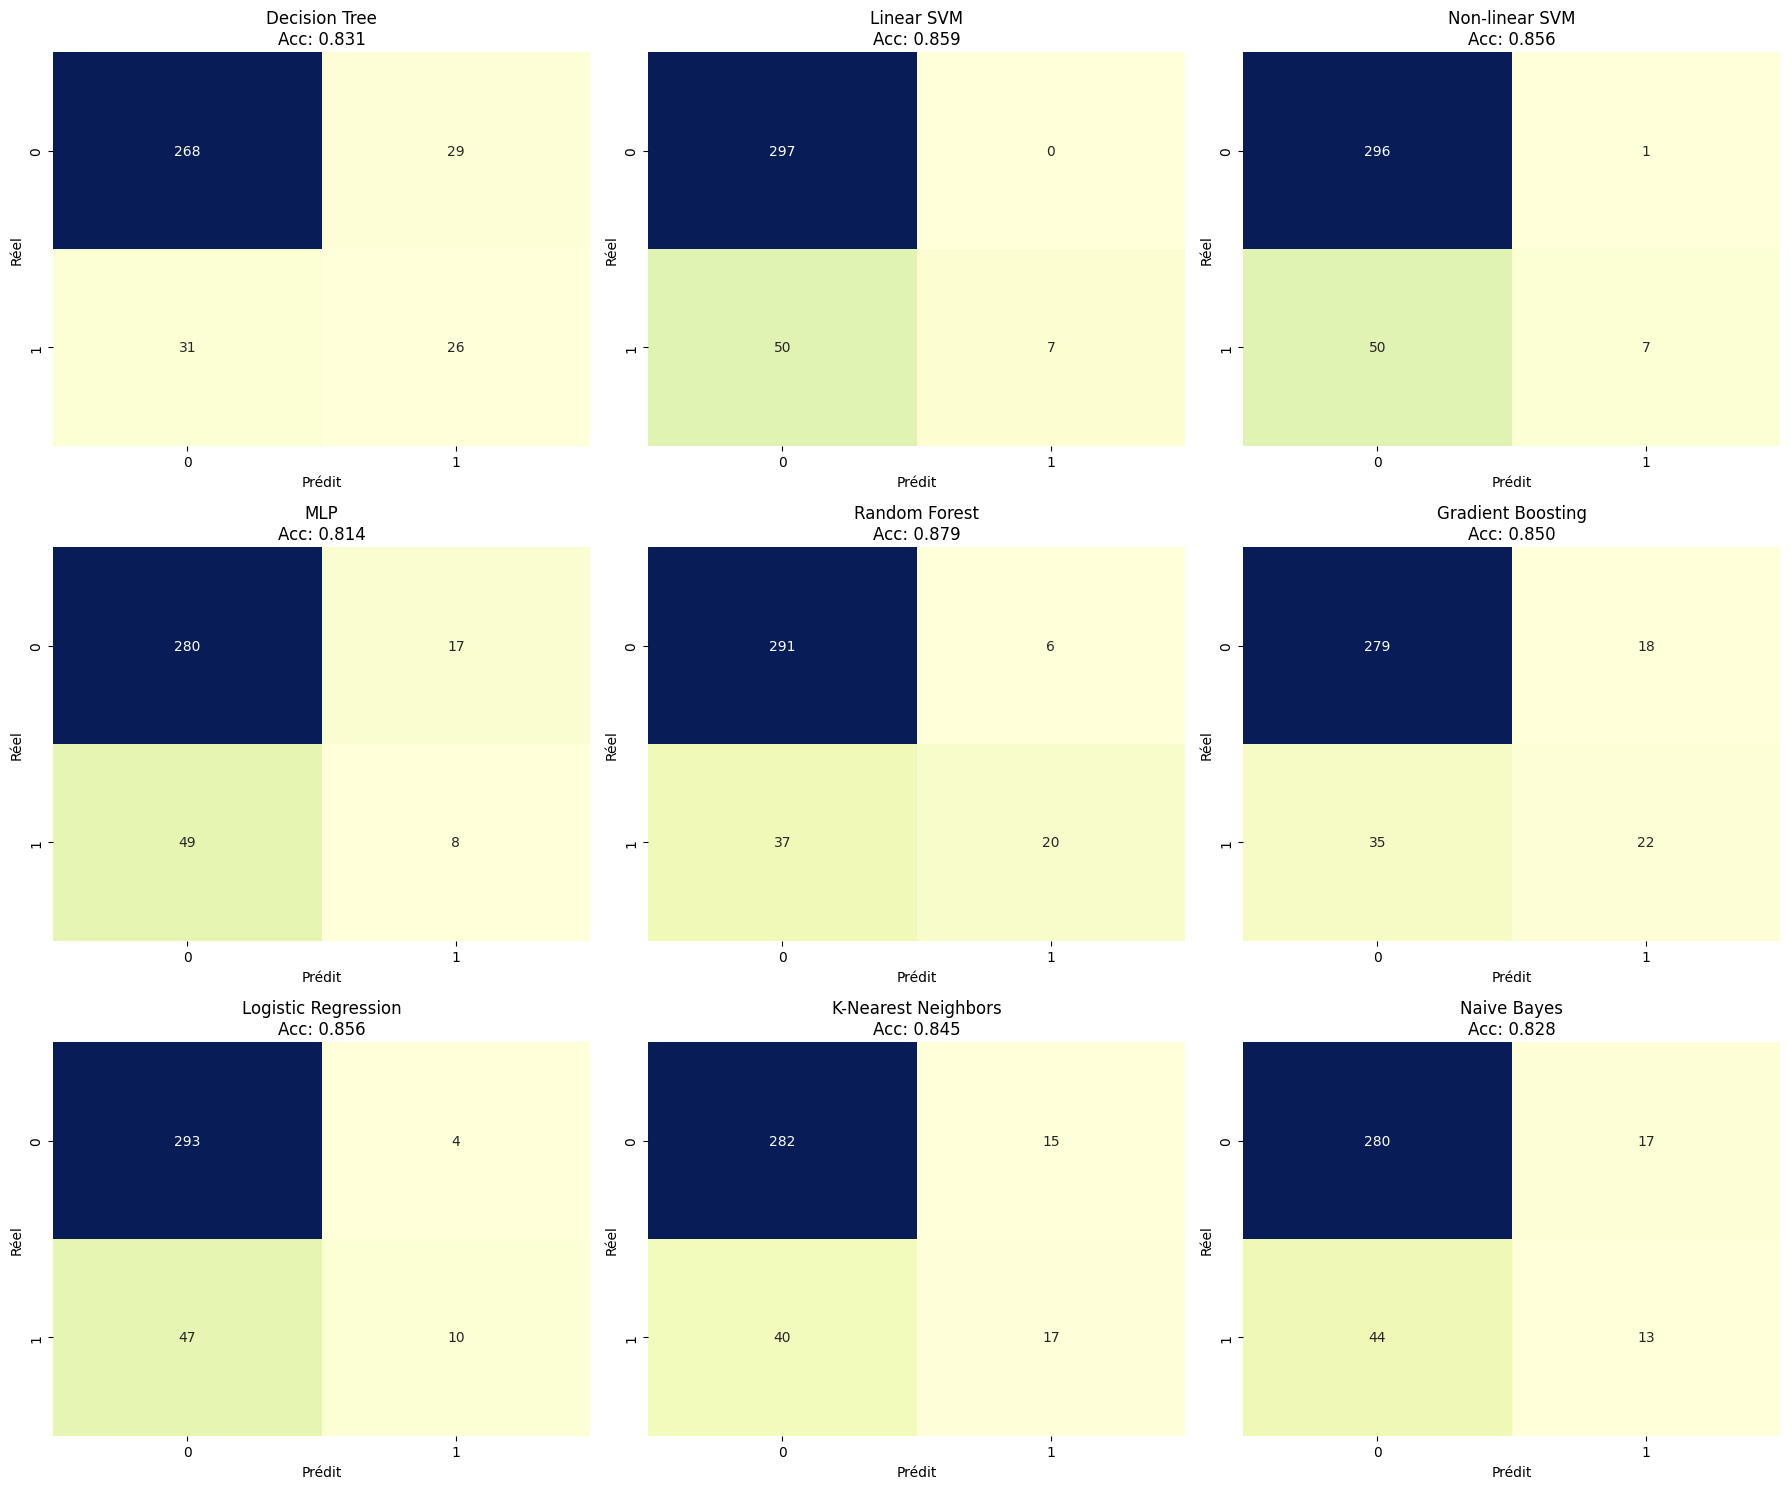

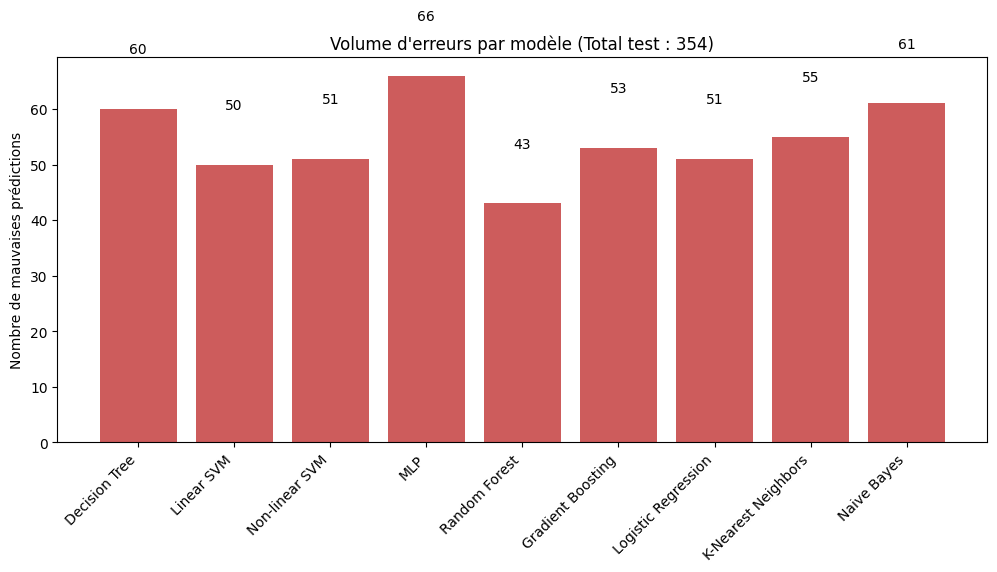

In [ ]:
import seaborn as sns
# --- Préparation des données de prédiction ---
# On crée un dictionnaire de prédictions pour ne pas recalculer sans cesse
all_preds = {}
for name, model in models.items():
    if "SVM" in name or "MLP" in name:
        all_preds[name] = model.predict(X_test_pca)
    else:
        all_preds[name] = model.predict(X_test)

# --- 1 & 2. Comparaison Accuracies et Distribution ---
plt.figure(figsize=(16, 6))

# Graphique de barres
plt.subplot(1, 2, 1)
model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())
sns.barplot(x=model_names, y=accuracy_values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Précision par Modèle')
plt.ylim(min(accuracy_values) - 0.05, 1.0)
for i, acc in enumerate(accuracy_values):
    plt.text(i, acc + 0.005, f'{acc:.3f}', ha='center')

# Pie chart du meilleur modèle
plt.subplot(1, 2, 2)
prediction_counts = pd.Series(all_preds[best_model_name]).value_counts()
plt.pie(prediction_counts, labels=le_income.classes_, autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=90)
plt.title(f'Répartition des prédictions\n(Meilleur modèle : {best_model_name})')
plt.show()

# --- 4. Comparaison des matrices de confusion (Grille 3x3 pour 8 modèles) ---
# On ajuste la grille à 3x3 pour accueillir tes 8 modèles
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, (name, pred) in enumerate(all_preds.items()):
    cm = pd.crosstab(y_test, pred, rownames=['Réel'], colnames=['Prédit'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nAcc: {accuracies[name]:.3f}')

# Cacher les graphiques vides (le 9ème si tu as 8 modèles)
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- 5. Analyse des erreurs ---
errors = {name: (y_test != pred).sum() for name, pred in all_preds.items()}
plt.figure(figsize=(12, 5))
plt.bar(errors.keys(), errors.values(), color='indianred')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Nombre de mauvaises prédictions')
plt.title('Volume d\'erreurs par modèle (Total test : ' + str(len(y_test)) + ')')
for i, err in enumerate(errors.values()):
    plt.text(i, err + 10, str(err), ha='center')
plt.show()

# IRIS

In [21]:
dataPath = 'Data' # path to folder containing the Iris data
dataFile = os.path.join(dataPath,'iris.data') # data file to use

In [23]:
# Let's assign column names ('FType' stands for 'Flower Type')
import os

# Construct the correct absolute path to 'iris.data'
# This assumes the 'Data' folder is located within '/content/drive/MyDrive/COS302'
correct_data_path_iris = os.path.join('/content', 'drive', 'MyDrive', 'COS302', 'Data')
dataFile_iris = os.path.join(correct_data_path_iris, 'iris.data')

fullDF = pd.read_csv(dataFile_iris, header=None, names=['sepalL','sepalW','petalL','petalW','FType'])
fullDF.sample(10) # Let's take a random sample from the full data frame

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/COS302/Data/iris.data'